<a href="https://colab.research.google.com/github/JoseLLoredoHdz/mineria/blob/main/Ejercicio_de_K_NN_178446.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ejercicio de K-NN
178446 - Jose Luis Loredo Hernandez


Simulando 100 particiones aleatorias (80% Train / 20% Test)


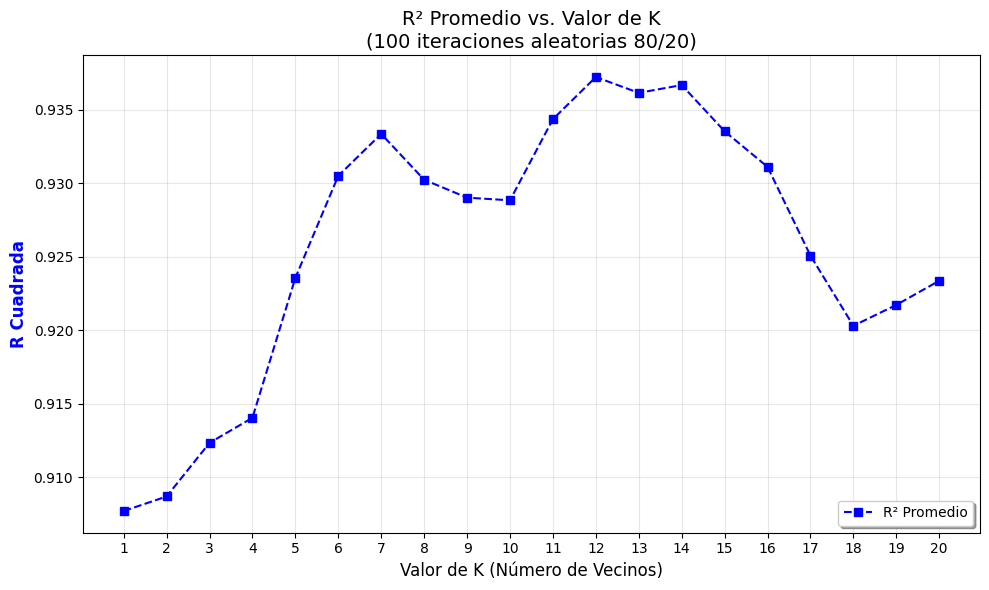

--- ANÁLISIS DE R CUADRADA (100 ITERACIONES) ---
Mejor valor de K detectado: 12
R^2 Promedio máximo: 0.9372


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import r2_score, accuracy_score

#dataset
iris = load_iris()
X, y = iris.data, iris.target

#Configuración de la simulación
k_max = 20
iteraciones = 100
# Matrices para guardar los resultados de cada "universo" de datos
matriz_r2 = np.zeros((iteraciones, k_max))

print(f"Simulando {iteraciones} particiones aleatorias (80% Train / 20% Test)")

for i in range(iteraciones):
    # 80% Entrenamiento, 20% Prueba
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

    # Estandarización
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for k in range(1, k_max + 1):
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train_scaled, y_train)
        y_pred = knn.predict(X_test_scaled)

        # Guardamos métricas
        matriz_r2[i, k-1] = r2_score(y_test, y_pred)

#Promediamos los resultados de las 100 pruebas
r2_promedio = np.mean(matriz_r2, axis=0)

# Gráfica de R^2 (Ajuste del modelo)
plt.figure(figsize=(10, 6))
plt.plot(range(1, k_max + 1), r2_promedio, color='blue', linestyle='--', marker='s', label='R² Promedio')

# Formato de la gráfica
plt.title('R² Promedio vs. Valor de K\n(100 iteraciones aleatorias 80/20)', fontsize=14)
plt.xlabel('Valor de K (Número de Vecinos)', fontsize=12)
plt.ylabel('R Cuadrada', fontsize=12, fontweight='bold', color='blue')
plt.xticks(range(1, k_max + 1))
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right', shadow=True)
plt.tight_layout()
plt.show()

# RESULTADOS FINALES
mejor_k = np.argmax(r2_promedio) + 1
print(f"--- ANÁLISIS DE R CUADRADA ({iteraciones} ITERACIONES) ---")
print(f"Mejor valor de K detectado: {mejor_k}")
print(f"R^2 Promedio máximo: {r2_promedio[mejor_k-1]:.4f}")

Evaluar el desempeño de KNN

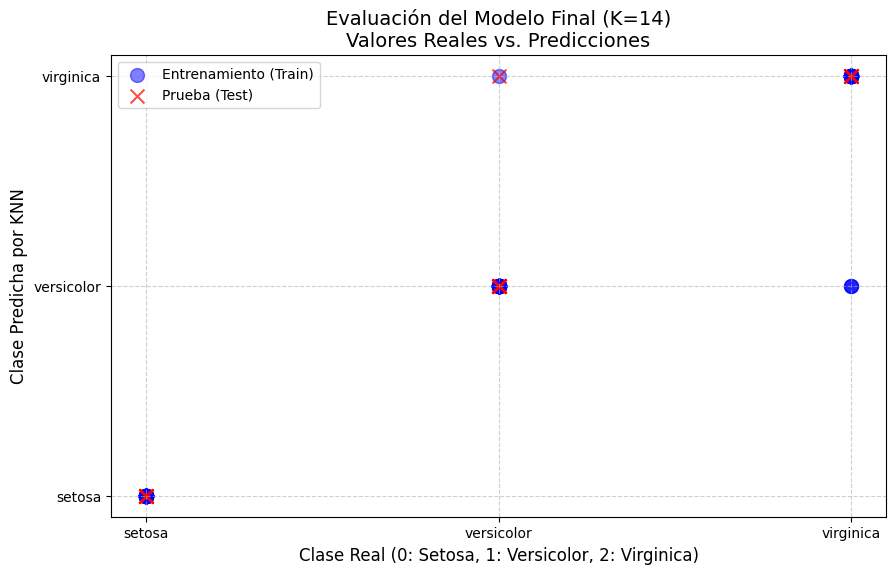

In [23]:
# Creamos el modelo con el K que detectamos como óptimo (K=12)
knn_final = KNeighborsClassifier(n_neighbors=12)

# Entrenamos con el último set de entrenamiento generado
knn_final.fit(X_train_scaled, y_train)

# Obtenemos las predicciones
train_predictions = knn_final.predict(X_train_scaled)
test_predictions = knn_final.predict(X_test_scaled)

# Gráfica de Valores Reales vs Predichos
plt.figure(figsize=(10, 6))

# Graficamos Entrenamiento
plt.scatter(y_train, train_predictions, color='blue', alpha=0.5, label='Entrenamiento (Train)', s=100)
# Graficamos Prueba
plt.scatter(y_test, test_predictions, color='red', alpha=0.7, label='Prueba (Test)', marker='x', s=100)

# Etiquetas y formato
plt.title(f'Evaluación del Modelo Final (K=14)\nValores Reales vs. Predicciones', fontsize=14)
plt.xlabel('Clase Real (0: Setosa, 1: Versicolor, 2: Virginica)', fontsize=12)
plt.ylabel('Clase Predicha por KNN', fontsize=12)
plt.xticks([0, 1, 2], iris.target_names)
plt.yticks([0, 1, 2], iris.target_names)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()


# El Método del Codo

El Método del Codo identifica el valor óptimo de $K$ donde el rendimiento ($R^2$) deja de mejorar significativamente. Este punto equilibra precisión y estabilidad, garantizando que el modelo clasifique datos nuevos correctamente.